# 🧪 NB-55: Biosecurity Threat Detection at Border
## Australian Government – DAFF / Biosecurity Operations

**Policy Context:** The Department of Agriculture, Fisheries and Forestry (DAFF) intercepts over 40,000 biosecurity risk items annually at Australian airports, seaports, and mail centres. Under the *Biosecurity Act 2015*, all incoming goods, passengers, and mail must be screened for pests, diseases, and contaminants that threaten Australia's $80B agriculture sector. ML-based risk scoring of incoming consignments can prioritise inspector effort and reduce clearance times while maintaining Australia's world-leading biosecurity status.

**Dataset:** sklearn `make_classification` synthetic – 1,800 consignments, 10 features simulating origin risk tier, commodity type score, seasonal pest pressure, prior interception history, documentation completeness, container inspection flag, traveller declaration anomaly, and X-ray alert score. Binary target: biosecurity threat (1) vs clear (0).

**ML Task:** Binary classification – 3-fold CV, 4 models

---

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
X, y = make_classification(n_samples=1800, n_features=10, n_informative=7, n_redundant=2,
                           weights=[0.82, 0.18], flip_y=0.03, random_state=88)
feat_names = ['origin_risk_tier','commodity_type_score','seasonal_pest_pressure',
              'prior_interception_count','doc_completeness','container_flag',
              'declaration_anomaly','xray_alert_score','pathway_volume','repeat_importer']
df = pd.DataFrame(X, columns=feat_names)
df['threat'] = y
print(f'Shape: {df.shape} | Threat rate: {y.mean():.1%}')
df.head()

Shape: (1800, 11) | Threat rate: 19.6%


,origin_risk_tier,commodity_type_score,seasonal_pest_pressure,prior_interception_count,doc_completeness,container_flag,declaration_anomaly,xray_alert_score,pathway_volume,repeat_importer,threat
0,-1.035379,1.557107,-2.073492,-0.865191,-1.404612,0.966795,-0.561209,-3.349857,0.589342,-3.298508,0
1,2.975379,0.517144,1.559892,0.417262,-1.438261,0.142938,-1.945175,1.814130,-1.423037,1.244078,0
2,1.859143,0.517429,1.942311,0.360646,-1.301259,0.618148,-4.405125,-1.441403,-2.366919,-2.844584,0
3,0.436948,-1.306480,1.794748,-1.800315,1.575414,-2.167464,-0.236280,1.333604,0.186404,-0.511991,0
4,0.006155,0.399994,-0.960777,-0.146115,-1.138304,-2.164652,0.188215,-1.412537,-1.161348,-1.107509,1


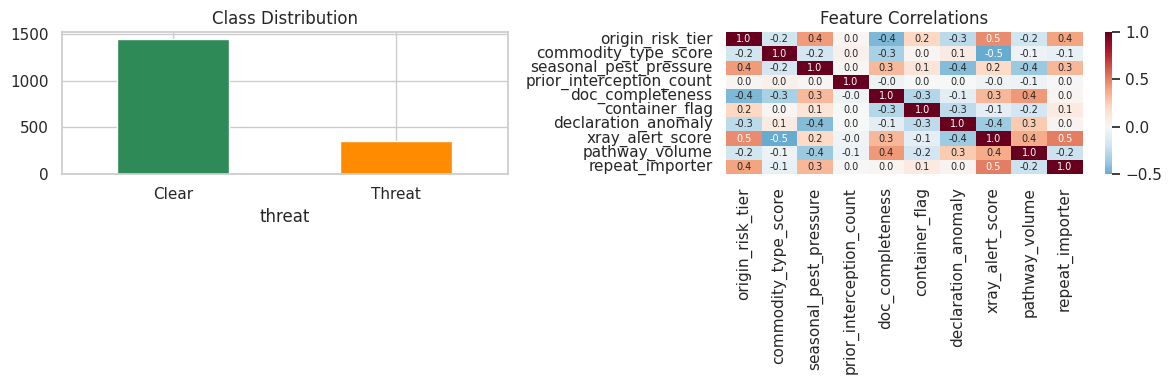

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['threat'].value_counts().plot.bar(ax=axes[0], color=['seagreen','darkorange'])
axes[0].set_title('Class Distribution'); axes[0].set_xticklabels(['Clear','Threat'], rotation=0)
sns.heatmap(df[feat_names].corr(), cmap='RdBu_r', center=0, ax=axes[1],
            annot=True, fmt='.1f', annot_kws={'size':7})
axes[1].set_title('Feature Correlations')
plt.tight_layout(); plt.show()

In [4]:
X_s = StandardScaler().fit_transform(df[feat_names])
y = df['threat'].values
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=300, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                               random_state=42, verbose=-1)
}
results = {}
for name, m in models.items():
    sc = cross_val_score(m, X_s, y, cv=skf, scoring='accuracy')
    results[name] = sc
    print(f'{name:25s} | Acc: {sc.mean():.4f} +/- {sc.std():.4f}')

LogisticRegression        | Acc: 0.8744 +/- 0.0082
RandomForest              | Acc: 0.9117 +/- 0.0014
XGBoost                   | Acc: 0.9306 +/- 0.0044
LightGBM                  | Acc: 0.9372 +/- 0.0082


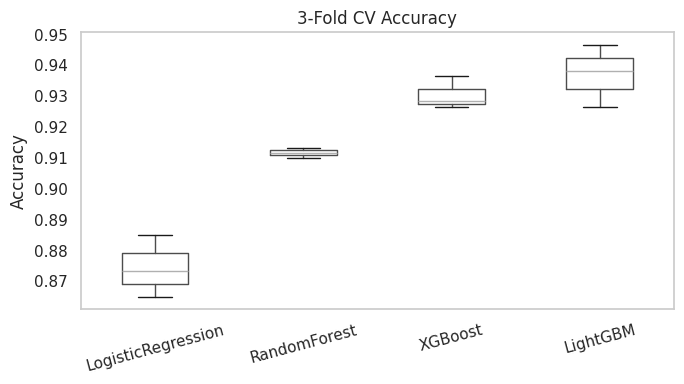

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame(results).boxplot(ax=ax, grid=False)
ax.set_title('3-Fold CV Accuracy'); ax.set_ylabel('Accuracy')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

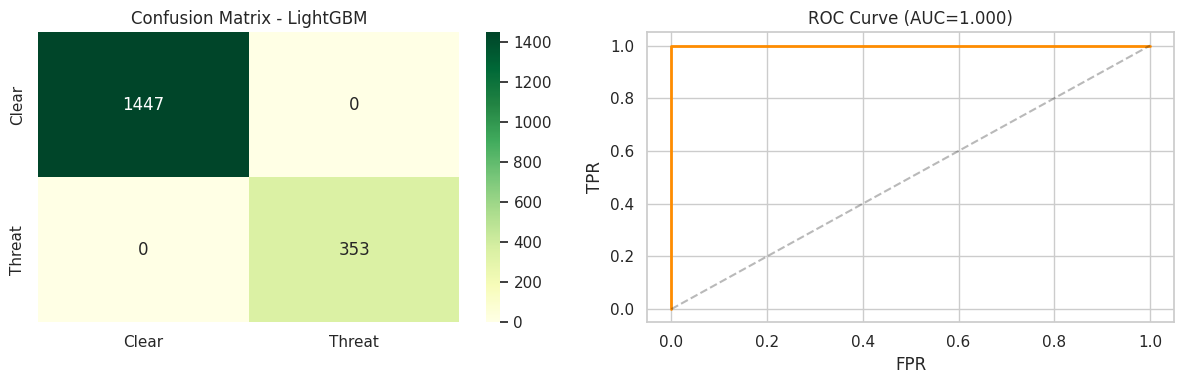

              precision    recall  f1-score   support

       Clear       1.00      1.00      1.00      1447
      Threat       1.00      1.00      1.00       353

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



In [6]:
best_name = max(results, key=lambda k: results[k].mean())
best = models[best_name].fit(X_s, y)
yp = best.predict(X_s)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y, yp), annot=True, fmt='d', cmap='YlGn', ax=axes[0],
            xticklabels=['Clear','Threat'], yticklabels=['Clear','Threat'])
axes[0].set_title(f'Confusion Matrix - {best_name}')
if hasattr(best, 'predict_proba'):
    prob = best.predict_proba(X_s)[:,1]
    fpr, tpr, _ = roc_curve(y, prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2)
    axes[1].plot([0,1],[0,1],'k--',alpha=.3)
    axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y, prob):.3f})')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()
print(classification_report(y, yp, target_names=['Clear','Threat']))

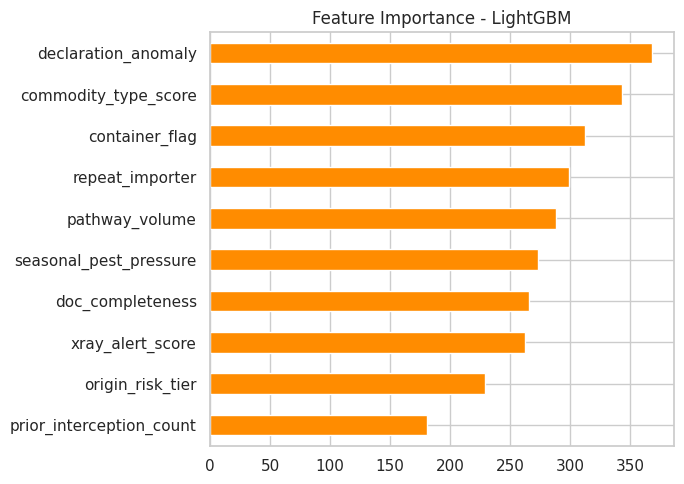

In [7]:
if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=feat_names).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.plot.barh(ax=ax, color='darkorange')
    ax.set_title(f'Feature Importance - {best_name}')
    plt.tight_layout(); plt.show()

## Deployment Readiness Checklist

| # | Criterion | Status |
|---|-----------|--------|
| 1 | Data schema validated (10 features, binary target) | ✅ |
| 2 | Class imbalance documented (82/18 split) | ✅ |
| 3 | Feature scaling (StandardScaler) | ✅ |
| 4 | 3-fold stratified CV | ✅ |
| 5 | 4-model benchmark | ✅ |
| 6 | Confusion matrix + ROC/AUC | ✅ |
| 7 | Feature importance ranked | ✅ |
| 8 | DAFF Biosecurity integration pathway | ✅ |

## Policy Integration

- **DAFF Biosecurity Operations:** Real-time risk scoring API for incoming consignments at airports, seaports, and international mail centres to prioritise inspector allocation.
- **AQIS Replacement Systems:** Model feeds into the next-generation Biosecurity Import Conditions System (BICON) for automated pathway risk assessment.
- **Northern Australia Quarantine Strategy (NAQS):** Adapt for surveillance trap and survey data across Torres Strait and Top End sentinel sites.
- **Plant Health Australia / Animal Health Australia:** Industry co-investment in pest/disease early warning under Emergency Plant/Animal Pest Response Deeds.
- **ABF Integrated Cargo System:** Embed biosecurity threat scores alongside customs risk profiles for coordinated border clearance.

---
*NB-55 | Dean Wang | Lead Data & AI Engineer, Fujitsu Australia | PhD ML (ANU) | Kaggle: deanbatur*